# PCA and K-Means

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

# 讀資料
df = pd.read_csv("mobile_price.csv")

print("Shape:", df.shape)
df.head(5)

Shape: (2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


a. Split the data (“mobile_price.csv”) into features and labels. Standardize the features using z-score standardization.

In [3]:
# split features / label
X = df.drop("price_range", axis=1)
y = df["price_range"]

# z-score standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 轉回 pandas DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Shape:", X_scaled_df.shape)
X_scaled_df.head(5)

Shape: (2000, 20)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,-0.902597,-0.990050,0.830779,-1.019184,-0.762495,-1.043966,-1.380644,0.340740,1.349249,-1.101971,-1.305750,-1.408949,-1.146784,0.391703,-0.784983,0.283103,1.462493,-1.786861,-1.006018,0.986097
1,-0.495139,1.010051,-1.253064,0.981177,-0.992890,0.957886,1.155024,0.687548,-0.120059,-0.664768,-0.645989,0.585778,1.704465,0.467317,1.114266,-0.635317,-0.734267,0.559641,0.994018,-1.014099
2,-1.537686,1.010051,-1.253064,0.981177,-0.532099,0.957886,0.493546,1.381165,0.134244,0.209639,-0.645989,1.392684,1.074968,0.441498,-0.310171,-0.864922,-0.368140,0.559641,0.994018,-1.014099
3,-1.419319,1.010051,1.198517,-1.019184,-0.992890,-1.043966,-1.215274,1.034357,-0.261339,0.646842,-0.151168,1.286750,1.236971,0.594569,0.876859,0.512708,-0.002014,0.559641,-1.006018,-1.014099
4,1.325906,1.010051,-0.395011,-1.019184,2.002254,0.957886,0.658915,0.340740,0.021220,-1.101971,0.673534,1.268718,-0.091452,-0.657666,-1.022389,-0.864922,0.730240,0.559641,0.994018,-1.014099


b. Following 4(a), project the features onto 2 dimensions using PCA and visualize the scatterplot for the first two principal components of the data.

Explained variance ratio: [0.08386288 0.08112475]


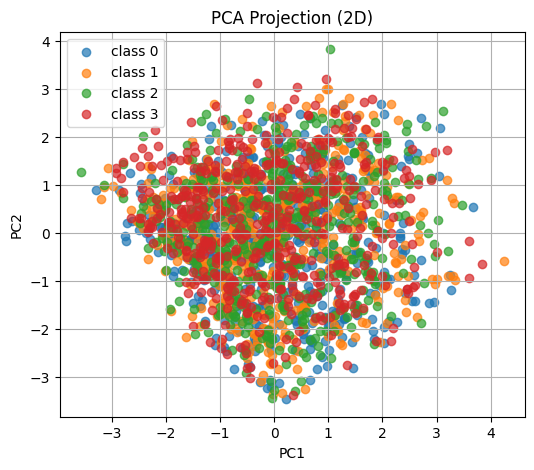

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)


plt.figure(figsize=(6,5))

for label in np.unique(y):
    idx = (y == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"class {label}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (2D)")
plt.legend()
plt.grid(True)
plt.show()

c. Following 4(a), apply K-means to cluster the data samples into 4 clusters using all features. Visualize the clustering results in a scatter plot (including a legend), and report the clustering performance.

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 評估（用真實 label）
ari = adjusted_rand_score(y, clusters)

print("KMeans (All features) ARI:", round(ari, 4))

KMeans (All features) ARI: 0.006


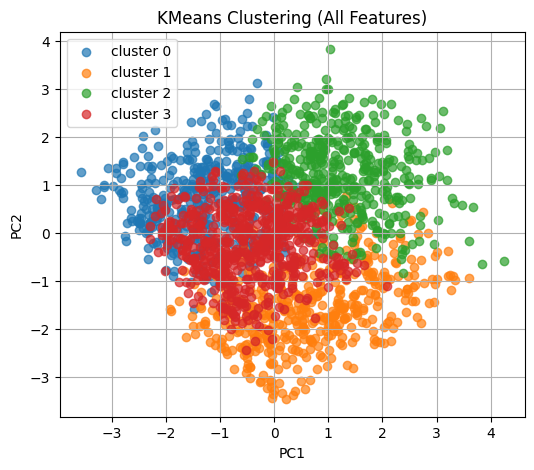

In [8]:
plt.figure(figsize=(6,5))

for c in np.unique(clusters):
    idx = (clusters == c)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering (All Features)")
plt.legend()
plt.grid(True)
plt.show()

d. Following 4(b), apply K-means to cluster the data samples into 4 clusters using the 2-dimensional features obtained from PCA. Visualize the clustering results with a scatter plot (including a legend), and report the clustering performance.

In [9]:
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# 評估
ari_pca = adjusted_rand_score(y, clusters_pca)

print("KMeans (PCA 2D) ARI:", round(ari_pca, 4))

KMeans (PCA 2D) ARI: 0.0017


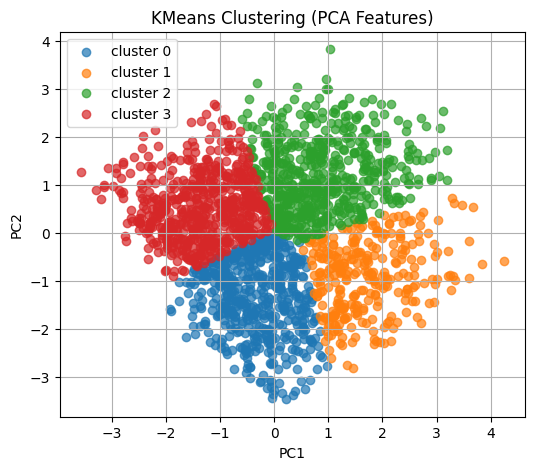

In [10]:
plt.figure(figsize=(6,5))

for c in np.unique(clusters_pca):
    idx = (clusters_pca == c)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clustering (PCA Features)")
plt.legend()
plt.grid(True)
plt.show()